# Volve 8 — closed-loop full-field development and operations

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/fielddevelopment/volve/08_volve_closed_loop_field_development_operations.ipynb)

**Principal Volve lifecycle capstone**

This notebook closes the loop from the static opportunity map to
producer/injector placement, OPM Flow cases, production-history
matching, NeqSim well and facility constraints, water injection,
late-life timing, shutdown, and decommissioning.

The authoritative measured-data boundary is Equinor's Volve Data
Village listing in Databricks Marketplace. Normal execution uses
an installed Marketplace Volume. The retained output was produced
with `VOLVE_VALIDATION_MODE=1`; it is marked
**DEMONSTRATION_FALLBACK** and is not a historical Volve result,
reserves estimate, development recommendation, or design
certification.


## Learning outcomes and engineering decisions

By completing the notebook, a reader can:

- turn static-model uncertainty into alternative development cases;
- select separated producer and injector candidates with explicit
  geological and facility objectives;
- write an OPM-compatible well schedule and run an OPM Flow
  history-match ensemble when a complete case is available;
- distinguish an executed OPM result from the stored reduced-model
  teaching bridge;
- feed separator, compression, water, export, injection, and SURF
  limits back into monthly reservoir controls;
- compare unconstrained potential with facility-constrained value;
- identify the economic limit and connect shutdown constraints to
  plugging, removal, monitoring, and decommissioning uncertainty.

The notebook consumes the versioned contracts written by notebooks
01, 04, 06, and 07 and writes a final lifecycle decision contract.


## Principal-collection coverage

| Lifecycle requirement | Primary evidence in the series | Capstone role |
|---|---|---|
| SEG-Y interpretation with `segyio` | notebook 01 | consumes the static handoff |
| Static model and development scenarios | notebooks 01–02 | compares explicit development cases |
| OPM Flow and history matching | notebooks 02 and 06 | supplies an OPM-primary ensemble runner and objective |
| Producer and injector placement | notebooks 03 and 08 | calculates locations, spacing, and schedules |
| IPR/VLP and nodal analysis | notebooks 03 and 07 | consumes per-well deliverability |
| Complete wells and gathering system | notebook 07 | consumes network backpressure and outage limits |
| Separation, compression, water, export, injection | notebooks 04 and 08 | closes produced-water and injection balances |
| Facility feedback to reservoir optimization | notebooks 05 and 08 | optimizes monthly choke and injection controls |
| Late life, shutdown, decommissioning | notebooks 07 and 08 | calculates economic limit and cessation exposure |


## Data provenance, licence, and software

- [Databricks Marketplace: Equinor Volve Data Village](https://marketplace.databricks.com/details/5c3558ef-315c-44dd-baef-7062ac301f22/Equinor-ASA_Volve-Data-Village)
- [Equinor Volve data sharing](https://www.equinor.com/energy/volve-data-sharing)
- [Equinor Volve open-data licence](https://www.equinor.com/content/dam/statoil/documents/what-we-do/Equinor-HRS-Terms-and-conditions-for-licence-to-data-Volve.pdf)
- [OPM Flow](https://opm-project.org/?page_id=19)
- [NeqSim](https://github.com/equinor/neqsim)
- [NeqSim Field Development and Operations book](https://equinor.github.io/neqsimhome/doc/field_development_and_operations/book_standalone.html)

The Marketplace package is not redistributed. Only explicitly
selected production and reservoir assets are read. OPM runs require
a complete local case directory because Eclipse/OPM decks commonly
depend on relative `INCLUDE` files. Credentials remain in Colab
Secrets or environment variables and are never printed.


## Clean-runtime setup and source policy

Normal Colab execution installs the Python bridges, clones current
`equinor/neqsim` master, records the resolved commit, builds its JAR,
and verifies the loaded class origin. Validation mode uses the
pinned public NeqSim 3.17.0 bridge. A real OPM acceptance run also
requires `flow`, OPM Python bindings, and the complete Volve case.


In [1]:
from importlib.metadata import version
import json
import math
import os
from pathlib import Path
import platform
import shutil
import subprocess
import sys


VALIDATION_MODE = os.environ.get("VOLVE_VALIDATION_MODE") == "1"
NEQSIM_SOURCE_REF = os.environ.get("NEQSIM_SOURCE_REF", "master")
NEQSIM_REPOSITORY_URL = "https://github.com/equinor/neqsim"

if not VALIDATION_MODE:
    packages = [
        "neqsim==3.17.0",
        "databricks-sdk==0.72.0",
        "openpyxl==3.1.5",
        "xlrd==2.0.2",
    ]
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", *packages],
        check=True,
        timeout=900,
    )
    source_dir = Path("/content/neqsim-master")
    if not source_dir.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                NEQSIM_SOURCE_REF,
                NEQSIM_REPOSITORY_URL,
                str(source_dir),
            ],
            check=True,
            timeout=300,
        )
    resolved_commit = subprocess.run(
        ["git", "-C", str(source_dir), "rev-parse", "HEAD"],
        capture_output=True,
        check=True,
        text=True,
        timeout=60,
    ).stdout.strip()
    subprocess.run(
        [str(source_dir / "mvnw"), "-q", "-DskipTests", "package"],
        check=True,
        cwd=source_dir,
        timeout=1800,
    )
    runtime_jars = sorted(
        (source_dir / "target").glob(
            "neqsim-*-jar-with-dependencies.jar"
        )
    )
    if not runtime_jars:
        raise RuntimeError("Current-master NeqSim JAR was not built.")
    os.environ["NEQSIM_JVM_AUTOSTART"] = "false"
    import jpype

    jpype.addClassPath(str(runtime_jars[-1]))
    jpype.startJVM(convertStrings=False)
else:
    resolved_commit = "release-3.17.0-validation-runtime"

from neqsim import jneqsim
from neqsim.thermo import TPflash

protection = (
    jneqsim.thermo.system.SystemSrkEos.class_
    .getProtectionDomain()
    .getCodeSource()
)
runtime_origin = (
    str(protection.getLocation()) if protection else "bundled JAR"
)
print(
    {
        "Python": platform.python_version(),
        "NeqSim bridge": version("neqsim"),
        "NeqSim source ref": NEQSIM_SOURCE_REF,
        "resolved commit": resolved_commit,
        "runtime origin": runtime_origin,
        "validation mode": VALIDATION_MODE,
    }
)


{'Python': '3.12.13', 'NeqSim bridge': '3.17.0', 'NeqSim source ref': 'master', 'resolved commit': 'release-3.17.0-validation-runtime', 'runtime origin': 'None', 'validation mode': True}


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.optimize import minimize

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120

series_dir = Path.cwd()
if not (series_dir / "volve_common.py").is_file():
    repository_dir = Path("/content/NeqSim-Colab")
    if not repository_dir.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "https://github.com/EvenSol/NeqSim-Colab.git",
                str(repository_dir),
            ],
            check=True,
            timeout=300,
        )
    series_dir = (
        repository_dir
        / "notebooks"
        / "fielddevelopment"
        / "volve"
    )
sys.path.insert(0, str(series_dir))

import volve_common as vc

work_dir = Path(
    os.environ.get("VOLVE_WORK_DIR", str(series_dir / "work"))
)
work_dir.mkdir(parents=True, exist_ok=True)
source = vc.resolve_source()
display(vc.source_table(source))


,item,value
0,resolved mode,demonstration-fallback
1,Marketplace listing,https://marketplace.databricks.com/details/5c3...
2,volume root,not mounted
3,credentials,none
4,measured Volve data loaded,False
5,claim boundary,Deterministic teaching fixtures are used. Resu...


## Marketplace inputs and versioned handoffs

The production workbook supplies monthly well rates. Earlier
contracts supply static uncertainty, facility capacities, the
fitted reservoir state, per-well deliverability, SURF pressure,
and shutdown constraints. Missing contracts are a workflow error
in normal mode; validation can reconstruct deterministic fixtures.


In [3]:
if source.mode == "marketplace-local-volume":
    inventory = vc.inventory_local_volume(Path(source.volume_root))
elif source.mode == "marketplace-remote-volume":
    inventory = vc.list_remote_directory(source.volume_root)
else:
    inventory = vc.demonstration_inventory()

if source.measured_data_loaded:
    production_relative_path = vc.select_asset(
        inventory,
        "production-history",
        environment_name="VOLVE_PRODUCTION_PATH",
    )
    production_path = vc.materialize_asset(
        source,
        inventory,
        production_relative_path,
        work_dir / "marketplace_inputs",
    )
    production = vc.read_production_history(production_path)
    production_provenance = dict(production.attrs)
else:
    production_relative_path = "DEMONSTRATION_FALLBACK"
    production = vc.demo_production_history()
    production_provenance = {
        "source_path": "deterministic teaching fixture",
        "source_sha256": None,
        "normalized_rows": len(production),
    }

contract_paths = {
    "static": work_dir / "01_geoscience_static_model.json",
    "facilities": work_dir / "04_facilities_capacity_emissions.json",
    "reservoir": work_dir / "06_reservoir_history_match.json",
    "surf": work_dir / "07_all_wells_gathering_surf.json",
}
contracts = {
    name: vc.read_contract(path)
    for name, path in contract_paths.items()
    if path.is_file()
}
contract_registry = pd.DataFrame(
    [
        {
            "contract": name,
            "path": str(path),
            "available": name in contracts,
            "data_status": contracts.get(name, {}).get(
                "data_status",
                "missing",
            ),
        }
        for name, path in contract_paths.items()
    ]
)
display(pd.DataFrame([production_provenance]))
display(contract_registry)


,source_path,source_sha256,normalized_rows
0,deterministic teaching fixture,None,520


,contract,path,available,data_status
0,static,/workspace/scratch/95ecac0092cf/neqsim-colab-v...,True,DEMONSTRATION_FALLBACK
1,facilities,/workspace/scratch/95ecac0092cf/neqsim-colab-v...,True,DEMONSTRATION_FALLBACK
2,reservoir,/workspace/scratch/95ecac0092cf/neqsim-colab-v...,True,DEMONSTRATION_FALLBACK
3,surf,/workspace/scratch/95ecac0092cf/neqsim-colab-v...,True,DEMONSTRATION_FALLBACK


## 1. Static opportunity map and development scenarios

Notebook 01 performs SEG-Y geometry and amplitude QC, horizon
interpretation, depth conversion, well-log petrophysics, and STOIIP
uncertainty. The present capstone converts that handoff into a
scenario grid. The retained grid is deliberately synthetic and
preserves no proprietary coordinates.

Four cases are screened: three producers/one injector, four/one,
four/two, and five/two. They represent decisions, not the historical
Volve well plan.


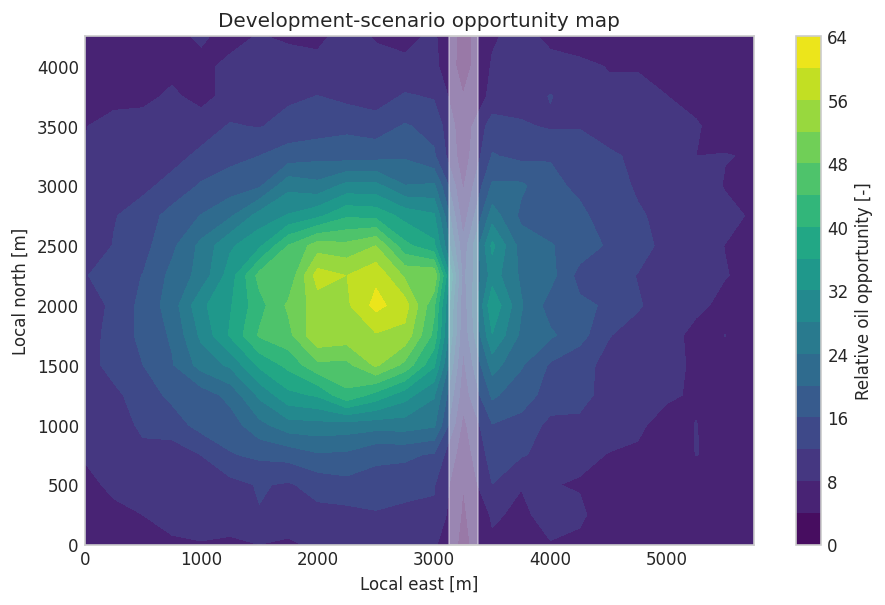

In [4]:
random = np.random.default_rng(20260815)
x_index = np.arange(24)
y_index = np.arange(18)
grid_x, grid_y = np.meshgrid(x_index, y_index)
structural_high = np.exp(
    -(
        (grid_x - 9.0) ** 2 / 45.0
        + (grid_y - 8.0) ** 2 / 28.0
    )
)
secondary_high = 0.65 * np.exp(
    -(
        (grid_x - 17.0) ** 2 / 22.0
        + (grid_y - 11.0) ** 2 / 18.0
    )
)
thickness_m = 14.0 + 29.0 * structural_high + 15.0 * secondary_high
porosity_fraction = 0.16 + 0.095 * structural_high
porosity_fraction += random.normal(0.0, 0.008, grid_x.shape)
permeability_md = 25.0 * np.exp(8.0 * (porosity_fraction - 0.16))
oil_saturation_fraction = 0.58 + 0.18 * structural_high
fault_barrier = np.abs(grid_x - 13.0) < 1.0
connectivity_fraction = np.where(fault_barrier, 0.35, 1.0)
cell_area_m2 = 250.0 * 250.0

opportunity = pd.DataFrame(
    {
        "i": grid_x.ravel() + 1,
        "j": grid_y.ravel() + 1,
        "x_m": grid_x.ravel() * 250.0,
        "y_m": grid_y.ravel() * 250.0,
        "thickness_m": thickness_m.ravel(),
        "porosity_fraction": porosity_fraction.ravel(),
        "permeability_md": permeability_md.ravel(),
        "oil_saturation_fraction": oil_saturation_fraction.ravel(),
        "connectivity_fraction": connectivity_fraction.ravel(),
    }
)
opportunity["oil_opportunity"] = (
    opportunity["thickness_m"]
    * opportunity["porosity_fraction"]
    * opportunity["oil_saturation_fraction"]
    * np.sqrt(opportunity["permeability_md"])
    * opportunity["connectivity_fraction"]
)

figure, axis = plt.subplots(figsize=(9, 5.5))
image = axis.contourf(
    grid_x * 250.0,
    grid_y * 250.0,
    opportunity["oil_opportunity"].to_numpy().reshape(grid_x.shape),
    levels=16,
    cmap="viridis",
)
axis.axvspan(12.5 * 250.0, 13.5 * 250.0, color="white", alpha=0.45)
axis.set(
    xlabel="Local east [m]",
    ylabel="Local north [m]",
    title="Development-scenario opportunity map",
)
figure.colorbar(image, ax=axis, label="Relative oil opportunity [-]")
plt.show()


## 2. Producer and injector placement

Producer candidates maximize movable oil, permeability, and
connectivity while maintaining a minimum well spacing. Injector
candidates favor connected, permeable edge cells that are neither
too close nor too far from the producer pattern.

$$S_p=h\phi S_o\sqrt{k}C_f$$

Here $h$ is net thickness in m, $\phi$ porosity, $S_o$ oil
saturation, $k$ permeability in mD, and $C_f$ a dimensionless
connectivity screen. Placement remains a multi-disciplinary
decision: drilling risk, faults, trajectory feasibility, pressure
communication, conformance, and facilities must be reviewed.


In [5]:
def distance_m(first, second):
    delta_x = float(first["x_m"] - second["x_m"])
    delta_y = float(first["y_m"] - second["y_m"])
    return math.hypot(delta_x, delta_y)


def select_spaced_candidates(table, count, score_column, spacing_m):
    selected_rows = []
    ordered = table.sort_values(score_column, ascending=False)
    for _, candidate in ordered.iterrows():
        separated = all(
            distance_m(candidate, existing) >= spacing_m
            for existing in selected_rows
        )
        if separated:
            selected_rows.append(candidate)
        if len(selected_rows) == count:
            break
    if len(selected_rows) != count:
        raise RuntimeError("Candidate spacing left too few locations.")
    return pd.DataFrame(selected_rows).reset_index(drop=True)


def place_pattern(producer_count, injector_count):
    producers = select_spaced_candidates(
        opportunity,
        producer_count,
        "oil_opportunity",
        spacing_m=900.0,
    )
    injector_candidates = opportunity.copy()
    injector_candidates["producer_distance_m"] = (
        injector_candidates.apply(
            lambda row: min(
                distance_m(row, producer)
                for _, producer in producers.iterrows()
            ),
            axis=1,
        )
    )
    distance_preference = np.exp(
        -(
            (injector_candidates["producer_distance_m"] - 1500.0)
            / 650.0
        )
        ** 2
    )
    injector_candidates["injection_opportunity"] = (
        injector_candidates["thickness_m"]
        * np.sqrt(injector_candidates["permeability_md"])
        * injector_candidates["connectivity_fraction"]
        * distance_preference
    )
    injector_candidates = injector_candidates.loc[
        injector_candidates["producer_distance_m"].between(
            750.0,
            2600.0,
        )
    ]
    injectors = select_spaced_candidates(
        injector_candidates,
        injector_count,
        "injection_opportunity",
        spacing_m=1100.0,
    )
    producers = producers.assign(well_type="PRODUCER")
    injectors = injectors.assign(well_type="INJECTOR")
    producers["well"] = [
        f"VP-{index:02d}"
        for index in range(1, producer_count + 1)
    ]
    injectors["well"] = [
        f"VI-{index:02d}"
        for index in range(1, injector_count + 1)
    ]
    return pd.concat([producers, injectors], ignore_index=True)


development_cases = pd.DataFrame(
    [
        {"case": "3P-1I", "producers": 3, "injectors": 1},
        {"case": "4P-1I", "producers": 4, "injectors": 1},
        {"case": "4P-2I", "producers": 4, "injectors": 2},
        {"case": "5P-2I", "producers": 5, "injectors": 2},
    ]
)
patterns = {
    row.case: place_pattern(row.producers, row.injectors)
    for row in development_cases.itertuples(index=False)
}
display(patterns["4P-2I"])


,i,j,x_m,y_m,thickness_m,porosity_fraction,permeability_md,oil_saturation_fraction,connectivity_fraction,oil_opportunity,well_type,well,producer_distance_m,injection_opportunity
0,11.0,9.0,2500.0,2000.0,43.000288,0.256292,54.012217,0.756044,1.0,61.234929,PRODUCER,VP-01,NaN,NaN
1,7.0,10.0,1500.0,2250.0,36.942091,0.243570,48.785703,0.722201,1.0,45.388941,PRODUCER,VP-02,NaN,NaN
2,9.0,6.0,2000.0,1250.0,34.599341,0.227528,42.909908,0.707652,1.0,36.492345,PRODUCER,VP-03,NaN,NaN
3,15.0,9.0,3500.0,2000.0,34.567030,0.228026,43.081036,0.683276,1.0,35.349657,PRODUCER,VP-04,NaN,NaN
4,19.0,13.0,4500.0,3000.0,25.520329,0.180595,29.477734,0.596803,1.0,14.933771,INJECTOR,VI-01,1414.213562,136.165963
5,12.0,14.0,2750.0,3250.0,26.384991,0.196546,33.490030,0.647438,1.0,19.430246,INJECTOR,VI-02,1274.754878,135.413831


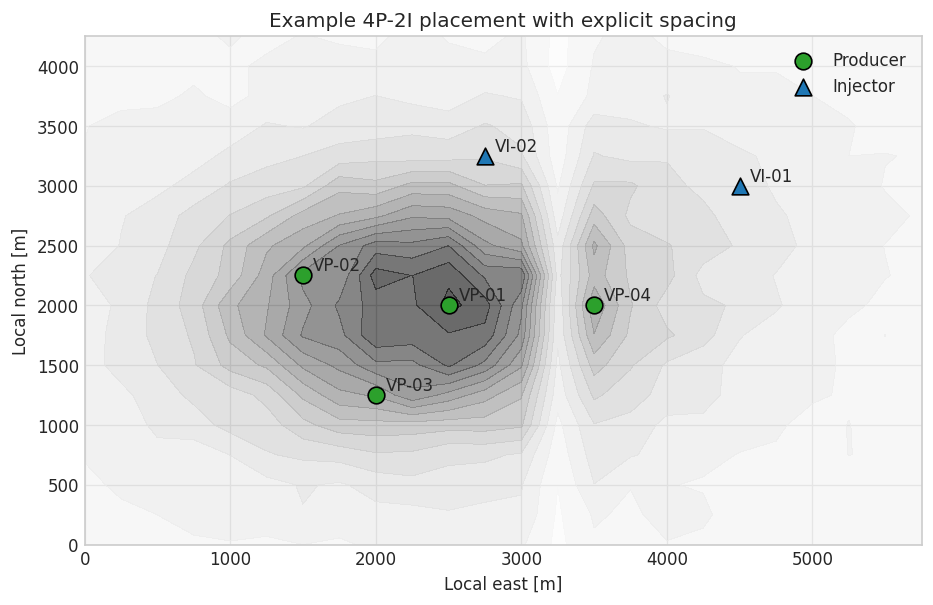

In [6]:
pattern = patterns["4P-2I"]
figure, axis = plt.subplots(figsize=(9, 5.5))
axis.contourf(
    grid_x * 250.0,
    grid_y * 250.0,
    opportunity["oil_opportunity"].to_numpy().reshape(grid_x.shape),
    levels=16,
    cmap="Greys",
    alpha=0.65,
)
for well_type, marker, color in [
    ("PRODUCER", "o", "tab:green"),
    ("INJECTOR", "^", "tab:blue"),
]:
    subset = pattern.loc[pattern["well_type"].eq(well_type)]
    axis.scatter(
        subset["x_m"],
        subset["y_m"],
        marker=marker,
        color=color,
        edgecolor="black",
        s=100,
        label=well_type.title(),
    )
    for row in subset.itertuples(index=False):
        axis.annotate(row.well, (row.x_m + 70.0, row.y_m + 40.0))
axis.set(
    xlabel="Local east [m]",
    ylabel="Local north [m]",
    title="Example 4P-2I placement with explicit spacing",
)
axis.legend()
plt.show()


## 3. OPM Flow schedule and history-match contract

OPM Flow is the primary full reservoir simulator for this capstone.
The notebook writes `WELSPECS`, `COMPDAT`, `WCONPROD`, and
`WCONINJE` records from the selected pattern. Set:

- `VOLVE_RUN_OPM_FLOW=1`;
- `VOLVE_OPM_CASE_ROOT` to a complete local case directory;
- `VOLVE_OPM_DECK_NAME` to the root deck filename; and
- optionally `OPM_FLOW_EXECUTABLE`.

The runner copies the complete case, adds controlled pore-volume,
permeability, and connectivity multipliers, executes each realization,
and reads field summary vectors through OPM Python bindings. The
stored validation path executes the same objective with a reduced
response surface and labels it accordingly.


In [7]:
selected_pattern = patterns["4P-2I"].copy()

def opm_schedule_lines(pattern_table):
    lines = ["WELSPECS"]
    for row in pattern_table.itertuples(index=False):
        group = "PROD" if row.well_type == "PRODUCER" else "INJE"
        preferred_phase = (
            "OIL" if row.well_type == "PRODUCER" else "WATER"
        )
        lines.append(
            f" '{row.well}' '{group}' {int(row.i)} {int(row.j)} "
            f"1* '{preferred_phase}' /"
        )
    lines.extend(["/", "", "COMPDAT"])
    for row in pattern_table.itertuples(index=False):
        lines.append(
            f" '{row.well}' {int(row.i)} {int(row.j)} 1 3 "
            "'OPEN' 1* 1* 0.20 /"
        )
    lines.extend(["/", "", "WCONPROD"])
    producers = pattern_table.loc[
        pattern_table["well_type"].eq("PRODUCER")
    ]
    for row in producers.itertuples(index=False):
        lines.append(
            f" '{row.well}' 'OPEN' 'ORAT' 900.0 1* 1* 1* "
            "180.0 /"
        )
    lines.extend(["/", "", "WCONINJE"])
    injectors = pattern_table.loc[
        pattern_table["well_type"].eq("INJECTOR")
    ]
    for row in injectors.itertuples(index=False):
        lines.append(
            f" '{row.well}' 'WATER' 'OPEN' 'RATE' 1800.0 "
            "1* 320.0 /"
        )
    lines.append("/")
    return lines


schedule_path = work_dir / "08_development_schedule.inc"
schedule_path.write_text(
    "\n".join(opm_schedule_lines(selected_pattern)) + "\n",
    encoding="utf-8",
)
print(schedule_path.read_text(encoding="utf-8")[:1800])


WELSPECS
 'VP-01' 'PROD' 11 9 1* 'OIL' /
 'VP-02' 'PROD' 7 10 1* 'OIL' /
 'VP-03' 'PROD' 9 6 1* 'OIL' /
 'VP-04' 'PROD' 15 9 1* 'OIL' /
 'VI-01' 'INJE' 19 13 1* 'WATER' /
 'VI-02' 'INJE' 12 14 1* 'WATER' /
/

COMPDAT
 'VP-01' 11 9 1 3 'OPEN' 1* 1* 0.20 /
 'VP-02' 7 10 1 3 'OPEN' 1* 1* 0.20 /
 'VP-03' 9 6 1 3 'OPEN' 1* 1* 0.20 /
 'VP-04' 15 9 1 3 'OPEN' 1* 1* 0.20 /
 'VI-01' 19 13 1 3 'OPEN' 1* 1* 0.20 /
 'VI-02' 12 14 1 3 'OPEN' 1* 1* 0.20 /
/

WCONPROD
 'VP-01' 'OPEN' 'ORAT' 900.0 1* 1* 1* 180.0 /
 'VP-02' 'OPEN' 'ORAT' 900.0 1* 1* 1* 180.0 /
 'VP-03' 'OPEN' 'ORAT' 900.0 1* 1* 1* 180.0 /
 'VP-04' 'OPEN' 'ORAT' 900.0 1* 1* 1* 180.0 /
/

WCONINJE
 'VI-01' 'WATER' 'OPEN' 'RATE' 1800.0 1* 320.0 /
 'VI-02' 'WATER' 'OPEN' 'RATE' 1800.0 1* 320.0 /
/



The normalized history-match objective is:

$$J(\theta)=\sum_{v\in\{q_o,q_w,q_g,p\}}w_v\frac{1}{N_v}\sum_t\left(\frac{y_{v,t}^{sim}(\theta)-y_{v,t}^{obs}}{s_v}\right)^2$$

where $\theta$ contains pore-volume, permeability, and connectivity
multipliers; $w_v$ is the engineering weight; $N_v$ the number of
valid observations; and $s_v$ a robust scale in the units of each
vector. A low scalar objective is not sufficient: well controls,
pressure support, saturation movement, solver diagnostics, and the
holdout period must remain physically credible.


In [8]:
field_history = vc.field_monthly_history(production)
pressure_screen = vc.reservoir_screen(production)
field_history["pressure_bara"] = pressure_screen[
    "average_pressure_bara"
].to_numpy()
elapsed_fraction = np.linspace(0.0, 1.0, len(field_history))

parameter_cases = pd.DataFrame(
    [
        {
            "case": f"HM-{case_number:02d}",
            "pore_volume_multiplier": pore_volume,
            "permeability_multiplier": permeability,
            "connectivity_multiplier": connectivity,
        }
        for case_number, (pore_volume, permeability, connectivity) in enumerate(
            [
                (0.90, 0.80, 0.75),
                (0.90, 1.15, 1.00),
                (1.00, 0.90, 1.00),
                (0.98, 1.02, 1.03),
                (1.00, 1.10, 1.25),
                (1.10, 0.85, 1.25),
                (1.10, 1.15, 0.80),
                (1.18, 1.00, 1.35),
            ],
            start=1,
        )
    ]
)

def reduced_history_response(parameters):
    pore_volume = parameters.pore_volume_multiplier
    permeability = parameters.permeability_multiplier
    connectivity = parameters.connectivity_multiplier
    oil_observed = field_history["oil_rate_Sm3_day"].to_numpy()
    water_observed = field_history["water_rate_Sm3_day"].to_numpy()
    gas_observed = field_history["gas_rate_Sm3_day"].to_numpy()
    pressure_observed = field_history["pressure_bara"].to_numpy()
    oil_simulated = oil_observed * permeability
    oil_simulated *= np.exp(-0.55 * (pore_volume - 1.0) * elapsed_fraction)
    water_simulated = water_observed * (
        1.0 + 0.55 * (connectivity - 1.0) * elapsed_fraction
    )
    gas_simulated = gas_observed * (
        1.0 + 0.30 * (permeability - 1.0)
    )
    pressure_simulated = pressure_observed
    pressure_simulated += 12.0 * (connectivity - 1.0) * elapsed_fraction
    pressure_simulated -= 8.0 * (permeability - 1.0) * elapsed_fraction
    return {
        "oil": oil_simulated,
        "water": water_simulated,
        "gas": gas_simulated,
        "pressure": pressure_simulated,
    }


def normalized_history_objective(response):
    observed = {
        "oil": field_history["oil_rate_Sm3_day"].to_numpy(),
        "water": field_history["water_rate_Sm3_day"].to_numpy(),
        "gas": field_history["gas_rate_Sm3_day"].to_numpy(),
        "pressure": field_history["pressure_bara"].to_numpy(),
    }
    weights = {"oil": 0.35, "water": 0.25, "gas": 0.15, "pressure": 0.25}
    objective = 0.0
    for vector_name, observation in observed.items():
        robust_scale = max(
            float(np.nanpercentile(observation, 90)),
            1.0,
        )
        residual = (response[vector_name] - observation) / robust_scale
        objective += weights[vector_name] * float(np.mean(residual**2))
    return objective


In [9]:
run_opm_flow = os.environ.get("VOLVE_RUN_OPM_FLOW") == "1"
opm_executed = False
opm_case_results = []
opm_responses = {}

if run_opm_flow:
    if not source.measured_data_loaded:
        raise RuntimeError(
            "OPM acceptance requires the measured Marketplace source."
        )
    case_root_text = os.environ.get("VOLVE_OPM_CASE_ROOT", "")
    deck_name = os.environ.get("VOLVE_OPM_DECK_NAME", "")
    case_root = Path(case_root_text).expanduser()
    if not case_root.is_dir() or not deck_name:
        raise RuntimeError(
            "Set VOLVE_OPM_CASE_ROOT and VOLVE_OPM_DECK_NAME."
        )
    flow_executable = os.environ.get("OPM_FLOW_EXECUTABLE")
    flow_executable = flow_executable or shutil.which("flow")
    if not flow_executable:
        raise RuntimeError("OPM Flow executable was not found.")
    try:
        from opm.io.ecl import ESmry
    except ImportError as error:
        raise RuntimeError(
            "OPM Python bindings are required to read summary vectors."
        ) from error

    for parameters in parameter_cases.itertuples(index=False):
        realization_root = work_dir / "opm_history_match" / parameters.case
        if realization_root.exists():
            shutil.rmtree(realization_root)
        shutil.copytree(case_root, realization_root)
        multiplier_path = realization_root / "HM_MULTIPLIERS.INC"
        multiplier_path.write_text(
            "MULTIPLY\n"
            f" PORV {parameters.pore_volume_multiplier:.6f} /\n"
            f" PERMX {parameters.permeability_multiplier:.6f} /\n"
            f" PERMY {parameters.permeability_multiplier:.6f} /\n"
            f" PERMZ {parameters.permeability_multiplier:.6f} /\n"
            f" MULTX {parameters.connectivity_multiplier:.6f} /\n"
            f" MULTY {parameters.connectivity_multiplier:.6f} /\n"
            "/\n",
            encoding="utf-8",
        )
        deck_path = realization_root / deck_name
        deck_text = deck_path.read_text(encoding="utf-8")
        if "METRIC" not in deck_text.upper():
            raise RuntimeError(
                "The OPM history objective requires a METRIC deck."
            )
        schedule_index = deck_text.upper().find("SCHEDULE")
        if schedule_index < 0:
            raise RuntimeError("SCHEDULE keyword was not found in deck.")
        include_text = "INCLUDE\n 'HM_MULTIPLIERS.INC' /\n\n"
        deck_text = (
            deck_text[:schedule_index]
            + include_text
            + deck_text[schedule_index:]
        )
        deck_path.write_text(deck_text, encoding="utf-8")
        run = subprocess.run(
            [flow_executable, deck_path.name],
            cwd=realization_root,
            capture_output=True,
            text=True,
            timeout=3600,
        )
        if run.returncode != 0:
            raise RuntimeError(run.stdout[-1500:] + run.stderr[-1500:])
        summary_path = realization_root / f"{deck_path.stem}.SMSPEC"
        summary = ESmry(str(summary_path))
        summary_dates = pd.to_datetime(
            [str(date) for date in summary.dates]
        )
        if len(summary_dates) < 2:
            raise RuntimeError(
                "OPM summary contains fewer than two dates."
            )
        observed_time = field_history["date"].to_numpy(
            dtype="datetime64[ns]"
        ).astype("int64")
        simulated_time = summary_dates.to_numpy(
            dtype="datetime64[ns]"
        ).astype("int64")

        def aligned_summary(keyword):
            values = np.asarray(summary[keyword], dtype=float)
            if len(values) != len(simulated_time):
                raise RuntimeError(
                    f"{keyword} length does not match OPM dates."
                )
            return np.interp(
                observed_time,
                simulated_time,
                values,
            )

        opm_responses[parameters.case] = {
            "oil": aligned_summary("FOPR"),
            "water": aligned_summary("FWPR"),
            "gas": aligned_summary("FGPR"),
            "pressure": aligned_summary("FPR"),
        }
        opm_case_results.append(
            {
                "case": parameters.case,
                "final_FOPT_Sm3": float(summary["FOPT"][-1]),
                "final_FWPT_Sm3": float(summary["FWPT"][-1]),
                "final_FGPT_Sm3": float(summary["FGPT"][-1]),
                "minimum_FPR_bara": float(np.min(summary["FPR"])),
                "return_code": run.returncode,
            }
        )
    opm_executed = True

match_records = []
for parameters in parameter_cases.itertuples(index=False):
    response = (
        opm_responses[parameters.case]
        if opm_executed
        else reduced_history_response(parameters)
    )
    match_records.append(
        {
            "case": parameters.case,
            "pore_volume_multiplier": parameters.pore_volume_multiplier,
            "permeability_multiplier": parameters.permeability_multiplier,
            "connectivity_multiplier": parameters.connectivity_multiplier,
            "objective": normalized_history_objective(response),
            "simulator": (
                "OPM Flow"
                if opm_executed
                else "DEMONSTRATION_FALLBACK reduced response"
            ),
        }
    )
history_match_cases = pd.DataFrame(match_records).sort_values("objective")
best_match = history_match_cases.iloc[0]
display(history_match_cases)
if opm_case_results:
    display(pd.DataFrame(opm_case_results))


,case,pore_volume_multiplier,permeability_multiplier,connectivity_multiplier,objective,simulator
3,HM-04,0.98,1.02,1.03,0.000098,DEMONSTRATION_FALLBACK reduced response
2,HM-03,1.00,0.90,1.00,0.001426,DEMONSTRATION_FALLBACK reduced response
7,HM-08,1.18,1.00,1.35,0.002344,DEMONSTRATION_FALLBACK reduced response
4,HM-05,1.00,1.10,1.25,0.002513,DEMONSTRATION_FALLBACK reduced response
6,HM-07,1.10,1.15,0.80,0.003069,DEMONSTRATION_FALLBACK reduced response
1,HM-02,0.90,1.15,1.00,0.004251,DEMONSTRATION_FALLBACK reduced response
5,HM-06,1.10,0.85,1.25,0.005027,DEMONSTRATION_FALLBACK reduced response
0,HM-01,0.90,0.80,0.75,0.005957,DEMONSTRATION_FALLBACK reduced response


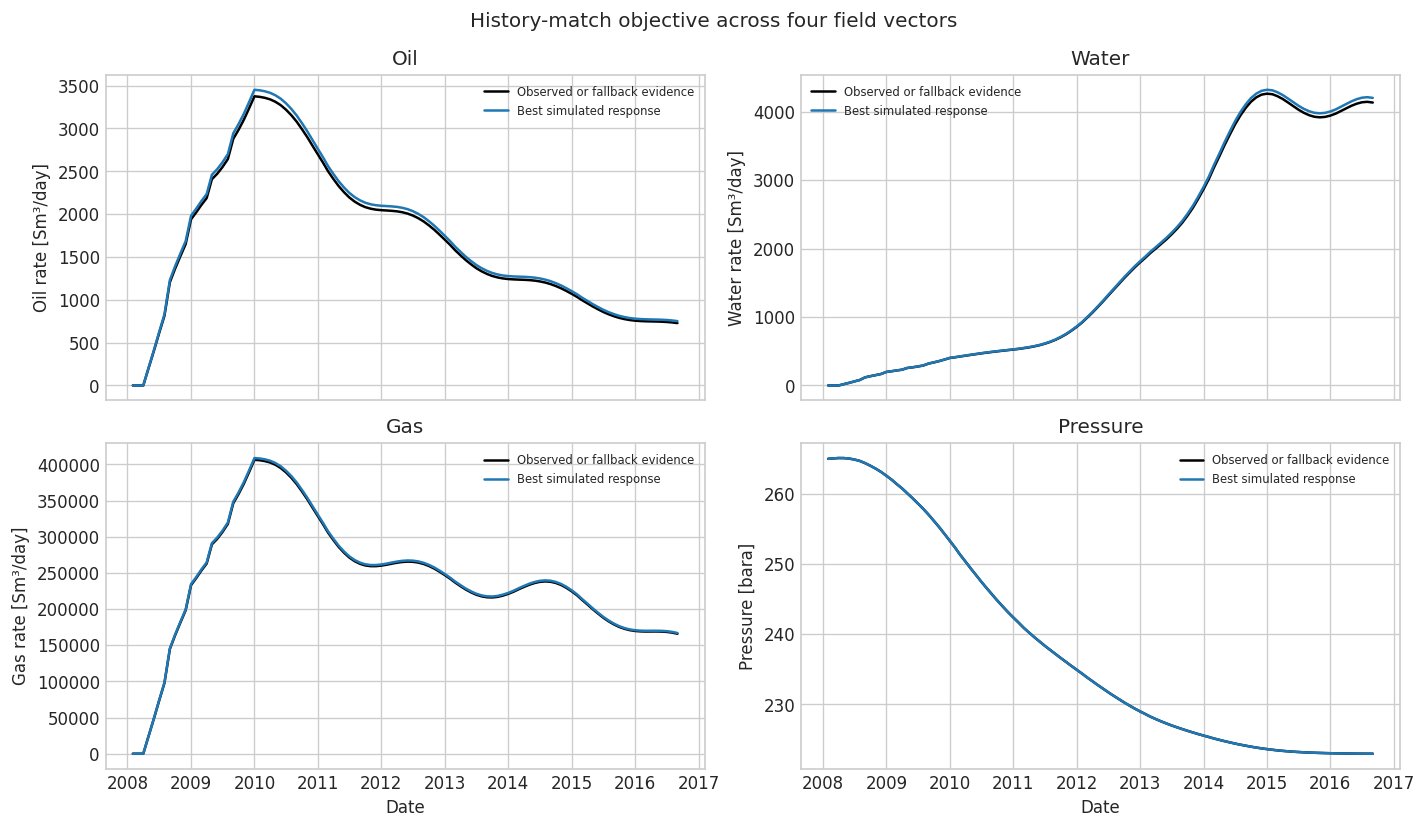

In [10]:
best_parameters = parameter_cases.loc[
    parameter_cases["case"].eq(best_match["case"])
].iloc[0]
best_response = (
    opm_responses[str(best_match["case"])]
    if opm_executed
    else reduced_history_response(best_parameters)
)

figure, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
comparison_vectors = [
    ("oil", "oil_rate_Sm3_day", "Oil rate [Sm³/day]"),
    ("water", "water_rate_Sm3_day", "Water rate [Sm³/day]"),
    ("gas", "gas_rate_Sm3_day", "Gas rate [Sm³/day]"),
    ("pressure", "pressure_bara", "Pressure [bara]"),
]
for axis, (response_name, column_name, label) in zip(
    axes.ravel(),
    comparison_vectors,
):
    axis.plot(
        field_history["date"],
        field_history[column_name],
        color="black",
        label="Observed or fallback evidence",
    )
    axis.plot(
        field_history["date"],
        best_response[response_name],
        color="tab:blue",
        label="Best simulated response",
    )
    axis.set(ylabel=label, title=response_name.title())
    axis.legend(fontsize=7)
axes[-1, 0].set_xlabel("Date")
axes[-1, 1].set_xlabel("Date")
figure.suptitle("History-match objective across four field vectors")
figure.tight_layout()
plt.show()


## 4. Facility, export, and injection constraints

Notebook 04 provides separation, gas compression, oil export,
produced-water treatment, power, and emissions evidence. Notebook
07 provides the common-riser and host-pressure boundary. The
capstone adds the missing injection side: NeqSim supplies water
density and the hydraulic calculation converts the chosen injection
rate and reservoir pressure into mass flow and pump power.

Every capacity below is an educational screen. It must be replaced
by approved operating envelopes for a real decision.


In [11]:
facility_contract = contracts.get("facilities", {})
process_records = pd.DataFrame(
    facility_contract.get("process_records", [])
)
bottleneck_records = pd.DataFrame(
    facility_contract.get("bottleneck_records", [])
)
water_records = pd.DataFrame(
    facility_contract.get("water_records", [])
)

facility_limits = {
    "oil_export_Sm3_day": 5000.0,
    "separator_liquid_Sm3_day": 9500.0,
    "water_treatment_Sm3_day": 6200.0,
    "gas_export_kg_s": 25.8,
    "water_injection_Sm3_day": 4000.0,
    "host_pressure_bara": 20.0,
}
if not bottleneck_records.empty:
    liquid_rows = bottleneck_records.loc[
        bottleneck_records["equipment"].eq("separator_liquid")
    ]
    if not liquid_rows.empty:
        facility_limits["separator_liquid_Sm3_day"] = float(
            liquid_rows["capacity"].max()
        )
if not process_records.empty:
    facility_limits["gas_export_kg_s"] = float(
        process_records["gas_product_kg_s"].max()
    )
if not water_records.empty:
    facility_limits["water_treatment_Sm3_day"] = float(
        water_records["water_rate_Sm3_day"].max()
    )
display(
    pd.DataFrame(
        {
            "constraint": facility_limits.keys(),
            "value": facility_limits.values(),
        }
    )
)


,constraint,value
0,oil_export_Sm3_day,5000.000000
1,separator_liquid_Sm3_day,9500.000000
2,water_treatment_Sm3_day,6200.000000
3,gas_export_kg_s,25.797627
4,water_injection_Sm3_day,4000.000000
5,host_pressure_bara,20.000000


In [12]:
injection_water = jneqsim.thermo.system.SystemSrkCPAstatoil(
    288.15,
    3.0,
)
injection_water.addComponent("water", 1.0)
injection_water.setMixingRule(10)
TPflash(injection_water)
water_density_kg_m3 = float(
    injection_water.getPhase(0).getDensity()
)

reference_injection_Sm3_day = 3000.0
injection_pressure_bara = 280.0
pump_suction_pressure_bara = 3.0
pump_efficiency_fraction = 0.78
injection_volume_m3_s = reference_injection_Sm3_day / 86400.0
injection_delta_pa = (
    injection_pressure_bara - pump_suction_pressure_bara
) * 1.0e5
injection_power_MW = (
    injection_volume_m3_s
    * injection_delta_pa
    / pump_efficiency_fraction
    / 1.0e6
)
injection_mass_kg_s = (
    injection_volume_m3_s * water_density_kg_m3
)
injection_reference = pd.DataFrame(
    {
        "quantity": [
            "NeqSim water density",
            "injection volume",
            "injection mass",
            "injection pressure",
            "hydraulic pump power",
        ],
        "value": [
            water_density_kg_m3,
            reference_injection_Sm3_day,
            injection_mass_kg_s,
            injection_pressure_bara,
            injection_power_MW,
        ],
        "unit": ["kg/m³", "Sm³/day", "kg/s", "bara", "MW"],
    }
)
display(injection_reference)


,quantity,value,unit
0,NeqSim water density,1011.951993,kg/m³
1,injection volume,3000.000000,Sm³/day
2,injection mass,35.137222,kg/s
3,injection pressure,280.000000,bara
4,hydraulic pump power,1.233084,MW


## 5. Closed-loop reservoir–well–SURF–facility optimization

At every month, the optimizer chooses the production choke fraction
$u_p$ and water-injection rate $q_{wi}$. It maximizes operating
margin while penalizing violations of oil export, separator liquid,
water treatment, gas compression, injection, and minimum-pressure
limits.

$$q_o=u_pq_{o,pot}(p,WC)$$

$$q_l=q_o+q_w\leq q_{l,max}$$

$$q_g\leq q_{g,max}$$

$$q_{wi}\leq q_{wi,max}$$

This is the central feedback: reservoir potential is not booked as
production when the well, SURF, process, export, water, or injection
system cannot handle it.


In [13]:
def simulate_closed_loop(
    producer_count,
    injector_count,
    *,
    facility_feedback,
    months=144,
):
    pressure_bara = 250.0
    water_cut = 0.08
    records = []
    for month in range(months):
        years = month / 12.0
        pressure_factor = np.clip(
            (pressure_bara - 120.0) / 130.0,
            0.0,
            1.15,
        )
        oil_potential = (
            producer_count
            * 1250.0
            * pressure_factor
            * math.exp(-0.045 * years)
        )
        gor_Sm3_Sm3 = 125.0 + 85.0 / (
            1.0 + math.exp(-(years - 6.0))
        )
        injection_capacity = min(
            injector_count * 2200.0,
            facility_limits["water_injection_Sm3_day"],
        )

        def rates(controls):
            choke_fraction, injection_fraction = controls
            injection_rate = injection_fraction * injection_capacity
            oil_rate = choke_fraction * oil_potential
            water_rate = oil_rate * water_cut / max(
                1.0 - water_cut,
                0.05,
            )
            gas_rate = oil_rate * gor_Sm3_Sm3
            gas_mass_kg_s = gas_rate * 0.82 / 86400.0
            liquid_rate = oil_rate + water_rate
            return {
                "oil": oil_rate,
                "water": water_rate,
                "gas": gas_rate,
                "gas_mass": gas_mass_kg_s,
                "liquid": liquid_rate,
                "injection": injection_rate,
            }

        def objective(controls):
            calculated = rates(controls)
            oil_margin_USD_day = calculated["oil"] * 62.0
            water_cost_USD_day = calculated["water"] * 5.5
            injection_cost_USD_day = calculated["injection"] * 2.2
            pressure_support_value = 7.5 * calculated["injection"]
            margin = (
                oil_margin_USD_day
                - water_cost_USD_day
                - injection_cost_USD_day
                + pressure_support_value
            )
            return -margin / 1.0e5

        constraints = []
        if facility_feedback:
            limit_pairs = [
                ("oil", "oil_export_Sm3_day"),
                ("liquid", "separator_liquid_Sm3_day"),
                ("water", "water_treatment_Sm3_day"),
                ("gas_mass", "gas_export_kg_s"),
                ("injection", "water_injection_Sm3_day"),
            ]
            constraints = [
                {
                    "type": "ineq",
                    "fun": lambda controls, rate_name=rate_name,
                    limit_name=limit_name: (
                        facility_limits[limit_name]
                        - rates(controls)[rate_name]
                    ),
                }
                for rate_name, limit_name in limit_pairs
            ]
        result = minimize(
            objective,
            x0=np.array([0.50, 0.60]),
            bounds=[(0.0, 1.0), (0.0, 1.0)],
            constraints=constraints,
            method="SLSQP" if facility_feedback else "L-BFGS-B",
            options={"ftol": 1.0e-9, "maxiter": 300},
        )
        if not result.success:
            raise RuntimeError(result.message)
        calculated = rates(result.x)
        pressure_change = (
            0.00024 * calculated["injection"]
            - 0.00031 * calculated["liquid"]
        )
        pressure_bara = float(
            np.clip(pressure_bara + pressure_change, 115.0, 270.0)
        )
        water_cut_change = 0.0010
        water_cut_change += 2.0e-7 * calculated["injection"]
        water_cut = float(
            np.clip(water_cut + water_cut_change, 0.05, 0.94)
        )
        gross_margin_USD_day = -objective(result.x) * 1.0e5
        records.append(
            {
                "month": month,
                "year": years,
                "pressure_bara": pressure_bara,
                "water_cut_fraction": water_cut,
                "choke_fraction": result.x[0],
                "oil_rate_Sm3_day": calculated["oil"],
                "water_rate_Sm3_day": calculated["water"],
                "gas_rate_Sm3_day": calculated["gas"],
                "gas_mass_kg_s": calculated["gas_mass"],
                "liquid_rate_Sm3_day": calculated["liquid"],
                "water_injection_Sm3_day": calculated["injection"],
                "gross_margin_USD_day": gross_margin_USD_day,
                "facility_feedback": facility_feedback,
            }
        )
    return pd.DataFrame(records)


screening_records = []
scenario_profiles = {}
for case in development_cases.itertuples(index=False):
    profile = simulate_closed_loop(
        case.producers,
        case.injectors,
        facility_feedback=True,
    )
    scenario_profiles[case.case] = profile
    cumulative_oil_MSm3 = float(
        profile["oil_rate_Sm3_day"].sum() * 30.4375 / 1.0e6
    )
    discounted_margin_MUSD = float(
        (
            profile["gross_margin_USD_day"]
            * 30.4375
            / (1.0 + 0.08) ** profile["year"]
        ).sum()
        / 1.0e6
    )
    drilling_cost_MUSD = 58.0 * case.producers
    drilling_cost_MUSD += 42.0 * case.injectors
    screening_records.append(
        {
            "case": case.case,
            "producers": case.producers,
            "injectors": case.injectors,
            "cumulative_oil_MSm3": cumulative_oil_MSm3,
            "discounted_operating_margin_MUSD": discounted_margin_MUSD,
            "well_cost_MUSD": drilling_cost_MUSD,
            "screening_value_MUSD": (
                discounted_margin_MUSD - drilling_cost_MUSD
            ),
        }
    )
development_screen = pd.DataFrame(screening_records)
development_screen = development_screen.sort_values(
    "screening_value_MUSD",
    ascending=False,
)
selected_case = str(development_screen.iloc[0]["case"])
selected_profile = scenario_profiles[selected_case]
display(development_screen)
print({"selected development case": selected_case})


{'selected development case': '5P-2I'}


,case,producers,injectors,cumulative_oil_MSm3,discounted_operating_margin_MUSD,well_cost_MUSD,screening_value_MUSD
3,5P-2I,5,2,15.145456,709.088462,374.0,335.088462
2,4P-2I,4,2,13.777362,646.411593,316.0,330.411593
1,4P-1I,4,1,11.571927,540.771154,274.0,266.771154
0,3P-1I,3,1,9.951601,461.139880,216.0,245.139880


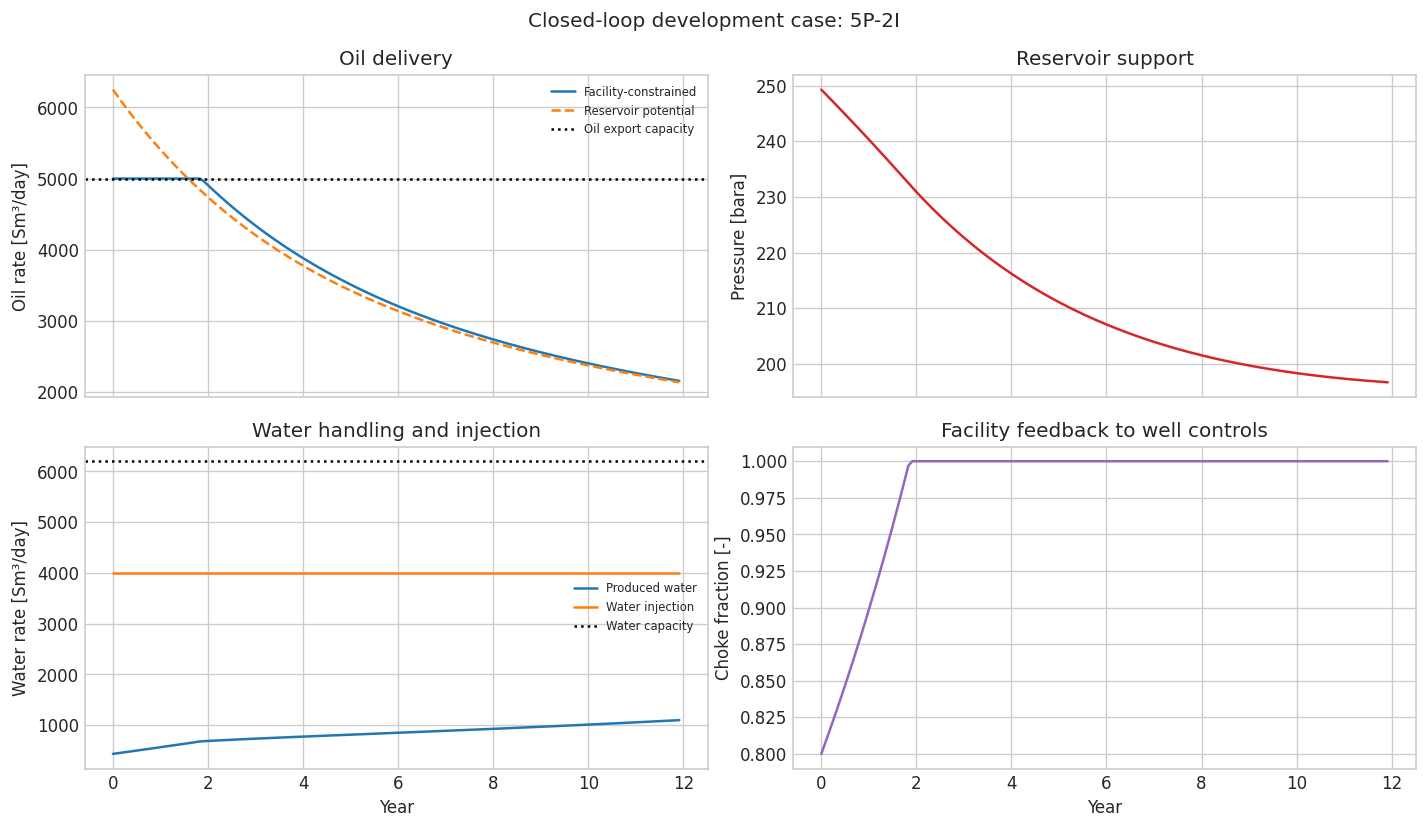

In [14]:
selected_row = development_cases.loc[
    development_cases["case"].eq(selected_case)
].iloc[0]
unconstrained_profile = simulate_closed_loop(
    int(selected_row["producers"]),
    int(selected_row["injectors"]),
    facility_feedback=False,
)

figure, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
axes[0, 0].plot(
    selected_profile["year"],
    selected_profile["oil_rate_Sm3_day"],
    label="Facility-constrained",
)
axes[0, 0].plot(
    unconstrained_profile["year"],
    unconstrained_profile["oil_rate_Sm3_day"],
    linestyle="--",
    label="Reservoir potential",
)
axes[0, 0].axhline(
    facility_limits["oil_export_Sm3_day"],
    color="black",
    linestyle=":",
    label="Oil export capacity",
)
axes[0, 0].set(ylabel="Oil rate [Sm³/day]", title="Oil delivery")
axes[0, 0].legend(fontsize=7)

axes[0, 1].plot(
    selected_profile["year"],
    selected_profile["pressure_bara"],
    color="tab:red",
)
axes[0, 1].set(ylabel="Pressure [bara]", title="Reservoir support")

axes[1, 0].plot(
    selected_profile["year"],
    selected_profile["water_rate_Sm3_day"],
    label="Produced water",
)
axes[1, 0].plot(
    selected_profile["year"],
    selected_profile["water_injection_Sm3_day"],
    label="Water injection",
)
axes[1, 0].axhline(
    facility_limits["water_treatment_Sm3_day"],
    color="black",
    linestyle=":",
    label="Water capacity",
)
axes[1, 0].set(
    xlabel="Year",
    ylabel="Water rate [Sm³/day]",
    title="Water handling and injection",
)
axes[1, 0].legend(fontsize=7)

axes[1, 1].plot(
    selected_profile["year"],
    selected_profile["choke_fraction"],
    color="tab:purple",
)
axes[1, 1].set(
    xlabel="Year",
    ylabel="Choke fraction [-]",
    title="Facility feedback to well controls",
)
figure.suptitle(f"Closed-loop development case: {selected_case}")
figure.tight_layout()
plt.show()


## 6. Late life, shutdown timing, and decommissioning

The economic limit is not simply the first low-rate month. The
screen requires six consecutive months of negative cash margin
after fixed operating expenditure. Shutdown planning then uses the
hydrate-safe cooldown window from notebook 07 and transitions to
isolation, well plugging and abandonment, subsea removal, facility
cleaning, waste/recycling, and environmental monitoring.

$$M_t=R_{o,t}-C_{w,t}-C_{e,t}-OPEX_{fixed,t}$$

The cessation date is the first month of a sustained negative
$M_t$, subject to integrity, regulation, contractual commitments,
and accountable asset review.


In [15]:
fixed_opex_USD_day = 185000.0
late_life = selected_profile.copy()
late_life["net_margin_USD_day"] = (
    late_life["gross_margin_USD_day"] - fixed_opex_USD_day
)
late_life["negative_margin"] = late_life[
    "net_margin_USD_day"
].lt(0.0)
sustained_negative = (
    late_life["negative_margin"]
    .rolling(6, min_periods=6)
    .sum()
    .eq(6)
)
if sustained_negative.any():
    end_index = int(np.flatnonzero(sustained_negative.to_numpy())[0])
    economic_limit_month = max(end_index - 5, 0)
else:
    economic_limit_month = len(late_life) - 1
economic_limit_year = economic_limit_month / 12.0

surf_contract = contracts.get("surf", {})
shutdown_contract = surf_contract.get("shutdown", {})
hydrate_window_h = float(
    shutdown_contract.get("time_to_hydrate_boundary_h", 18.0)
)
late_life_summary = pd.DataFrame(
    {
        "decision quantity": [
            "economic-limit month",
            "economic-limit year",
            "oil rate at economic limit",
            "water cut at economic limit",
            "hydrate-safe shutdown window",
        ],
        "value": [
            economic_limit_month,
            economic_limit_year,
            late_life.loc[
                economic_limit_month,
                "oil_rate_Sm3_day",
            ],
            late_life.loc[
                economic_limit_month,
                "water_cut_fraction",
            ],
            hydrate_window_h,
        ],
        "unit": ["month", "year", "Sm³/day", "fraction", "h"],
    }
)
display(late_life_summary)


,decision quantity,value,unit
0,economic-limit month,97.000000,month
1,economic-limit year,8.083333,year
2,oil rate at economic limit,2724.963646,Sm³/day
3,water cut at economic limit,0.256400,fraction
4,hydrate-safe shutdown window,18.000000,h


,phase,decision evidence,accountable output
0,isolate and make safe,"inventory, pressure, hydrate window",approved shutdown and isolation plan
1,plug and abandon wells,7 screened wells,verified permanent barriers
2,clean and remove facilities,hydrocarbon and chemical inventories,"cleaning, lifting, and waste records"
3,survey and monitor,seabed and environmental baseline,close-out and monitoring evidence


,percentile,decommissioning cost [MUSD]
0,P10,222.184726
1,P50,253.399415
2,P90,290.998954


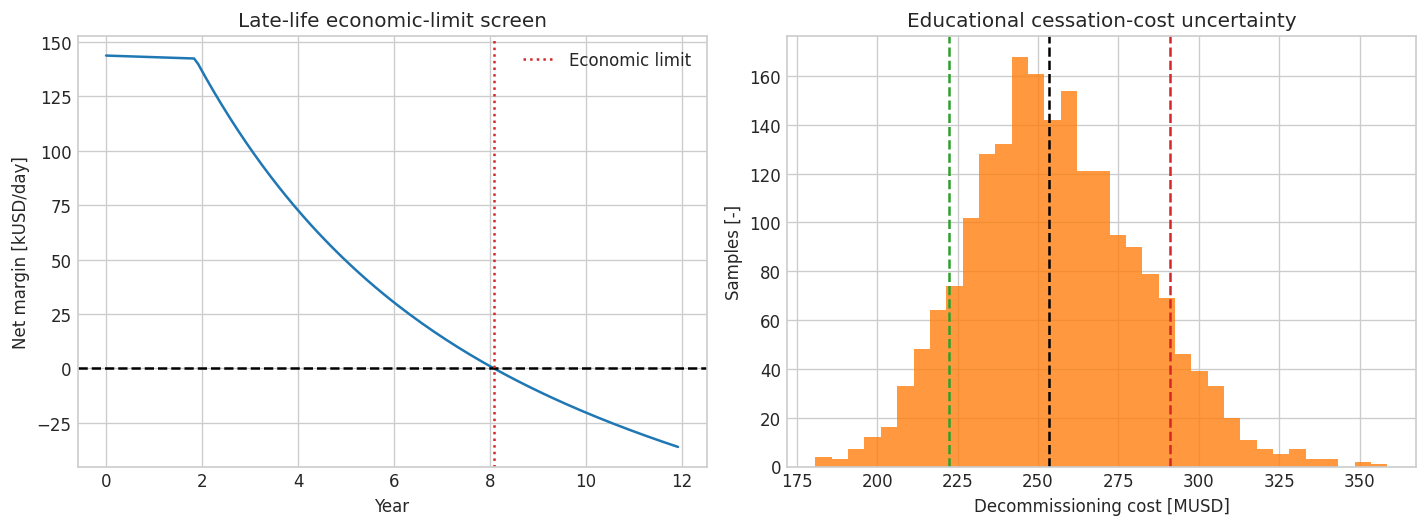

In [16]:
selected_pattern = patterns[selected_case]
well_count = len(selected_pattern)
decommission_random = np.random.default_rng(20260816)
sample_count = 2000
well_pa_cost_MUSD = decommission_random.lognormal(
    mean=math.log(14.0 * well_count),
    sigma=0.20,
    size=sample_count,
)
subsea_removal_MUSD = decommission_random.triangular(
    35.0,
    48.0,
    75.0,
    size=sample_count,
)
facility_cleaning_MUSD = decommission_random.triangular(
    55.0,
    82.0,
    125.0,
    size=sample_count,
)
monitoring_MUSD = decommission_random.triangular(
    12.0,
    20.0,
    36.0,
    size=sample_count,
)
recycling_credit_MUSD = decommission_random.triangular(
    3.0,
    7.0,
    13.0,
    size=sample_count,
)
decommission_cost_MUSD = (
    well_pa_cost_MUSD
    + subsea_removal_MUSD
    + facility_cleaning_MUSD
    + monitoring_MUSD
    - recycling_credit_MUSD
)
decommission_percentiles = np.percentile(
    decommission_cost_MUSD,
    [10, 50, 90],
)
decommissioning_plan = pd.DataFrame(
    [
        {
            "phase": "isolate and make safe",
            "decision evidence": "inventory, pressure, hydrate window",
            "accountable output": "approved shutdown and isolation plan",
        },
        {
            "phase": "plug and abandon wells",
            "decision evidence": f"{well_count} screened wells",
            "accountable output": "verified permanent barriers",
        },
        {
            "phase": "clean and remove facilities",
            "decision evidence": "hydrocarbon and chemical inventories",
            "accountable output": "cleaning, lifting, and waste records",
        },
        {
            "phase": "survey and monitor",
            "decision evidence": "seabed and environmental baseline",
            "accountable output": "close-out and monitoring evidence",
        },
    ]
)
display(decommissioning_plan)
display(
    pd.DataFrame(
        {
            "percentile": ["P10", "P50", "P90"],
            "decommissioning cost [MUSD]": decommission_percentiles,
        }
    )
)

figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(
    late_life["year"],
    late_life["net_margin_USD_day"] / 1000.0,
)
axes[0].axhline(0.0, color="black", linestyle="--")
axes[0].axvline(
    economic_limit_year,
    color="tab:red",
    linestyle=":",
    label="Economic limit",
)
axes[0].set(
    xlabel="Year",
    ylabel="Net margin [kUSD/day]",
    title="Late-life economic-limit screen",
)
axes[0].legend()
axes[1].hist(
    decommission_cost_MUSD,
    bins=35,
    color="tab:orange",
    alpha=0.8,
)
for percentile, color in zip(
    decommission_percentiles,
    ["tab:green", "black", "tab:red"],
):
    axes[1].axvline(percentile, color=color, linestyle="--")
axes[1].set(
    xlabel="Decommissioning cost [MUSD]",
    ylabel="Samples [-]",
    title="Educational cessation-cost uncertainty",
)
figure.tight_layout()
plt.show()


## 7. Decision crosswalk and limitations

| Decision | Evidence used | Result consumed next |
|---|---|---|
| Static opportunity | SEG-Y, horizons, logs, rock/fluid properties | development scenarios |
| Well pattern | opportunity, spacing, injectivity, well count | OPM schedule |
| Reservoir calibration | oil, water, gas, pressure, controls | forecast and uncertainty |
| Production technology | IPR/VLP, nodal point, choke, SURF pressure | well deliverability |
| Facilities | separation, compression, export, water, power | constrained controls |
| Operations | surveillance, allocation, outages, interventions | updated model state |
| Late life | margin, water, integrity, hydrate window | cessation date |
| Decommissioning | wells, inventories, removal and monitoring | accountable execution plan |

Limitations:

- the stored opportunity grid, well plan, reduced history response,
  economic terms, and decommissioning costs are teaching fixtures;
- a real OPM match must reconcile deck includes, well names, units,
  summary vectors, controls, convergence, restart saturation, and a
  blind holdout period;
- placement requires trajectory, drilling, geomechanics, fault,
  completion, intervention, and regulatory review;
- facility limits require approved equipment curves and operating
  envelopes; and
- cessation and decommissioning decisions require operator,
  partner, regulator, safety, environmental, and commercial review.


## 8. Executable validation

The assertions test provenance, spacing, producer/injector presence,
OPM schedule completeness, history-objective finiteness, NeqSim
water properties, facility constraint closure, economic-limit
ordering, and decommissioning uncertainty. They do not convert the
teaching case into measured Volve evidence.


In [17]:
selected_producers = selected_pattern.loc[
    selected_pattern["well_type"].eq("PRODUCER")
]
selected_injectors = selected_pattern.loc[
    selected_pattern["well_type"].eq("INJECTOR")
]
producer_distances = [
    distance_m(first, second)
    for first_index, first in selected_producers.iterrows()
    for second_index, second in selected_producers.iterrows()
    if first_index < second_index
]
facility_checks = {
    "oil export": (
        selected_profile["oil_rate_Sm3_day"].max()
        <= facility_limits["oil_export_Sm3_day"] * 1.001
    ),
    "separator liquid": (
        selected_profile["liquid_rate_Sm3_day"].max()
        <= facility_limits["separator_liquid_Sm3_day"] * 1.001
    ),
    "water treatment": (
        selected_profile["water_rate_Sm3_day"].max()
        <= facility_limits["water_treatment_Sm3_day"] * 1.001
    ),
    "gas export": (
        selected_profile["gas_mass_kg_s"].max()
        <= facility_limits["gas_export_kg_s"] * 1.001
    ),
    "water injection": (
        selected_profile["water_injection_Sm3_day"].max()
        <= facility_limits["water_injection_Sm3_day"] * 1.001
    ),
}
checks = {
    "explicit source status": source.mode in {
        "marketplace-local-volume",
        "marketplace-remote-volume",
        "demonstration-fallback",
    },
    "producer pattern": len(selected_producers) >= 3,
    "injector pattern": len(selected_injectors) >= 1,
    "producer spacing": min(producer_distances) >= 900.0,
    "OPM WELSPECS": "WELSPECS" in schedule_path.read_text(),
    "OPM production controls": "WCONPROD" in schedule_path.read_text(),
    "OPM injection controls": "WCONINJE" in schedule_path.read_text(),
    "finite history objective": np.isfinite(
        history_match_cases["objective"]
    ).all(),
    "NeqSim water density": 950.0 < water_density_kg_m3 < 1100.0,
    "positive injection power": injection_power_MW > 0.0,
    "optimizer records": len(selected_profile) == 144,
    "physical pressure": selected_profile["pressure_bara"].between(
        100.0,
        300.0,
    ).all(),
    "ordered economic limit": 0 <= economic_limit_month < 144,
    "ordered decommission percentiles": (
        decommission_percentiles[0]
        < decommission_percentiles[1]
        < decommission_percentiles[2]
    ),
    **facility_checks,
}
validation_table = pd.DataFrame(
    {
        "check": checks.keys(),
        "passed": checks.values(),
    }
)
display(validation_table)
failed_checks = validation_table.loc[~validation_table["passed"]]
if not failed_checks.empty:
    raise AssertionError(failed_checks["check"].tolist())
print(f"All {len(checks)} closed-loop lifecycle checks passed.")


All 19 closed-loop lifecycle checks passed.


,check,passed
0,explicit source status,True
1,producer pattern,True
2,injector pattern,True
3,producer spacing,True
4,OPM WELSPECS,True
5,OPM production controls,True
6,OPM injection controls,True
7,finite history objective,True
8,NeqSim water density,True
9,positive injection power,True


In [18]:
final_contract_path = work_dir / "08_closed_loop_lifecycle.json"
final_contract = vc.write_contract(
    final_contract_path,
    {
        "discipline": "closed-loop field development and operations",
        "data_status": (
            "MEASURED_VOLVE"
            if source.measured_data_loaded and opm_executed
            else "DEMONSTRATION_FALLBACK"
        ),
        "production_asset": production_relative_path,
        "opm_executed": opm_executed,
        "best_history_match": best_match.to_dict(),
        "selected_development_case": selected_case,
        "development_screen": development_screen.to_dict("records"),
        "selected_pattern": selected_pattern[
            ["well", "well_type", "i", "j", "x_m", "y_m"]
        ].to_dict("records"),
        "facility_limits": facility_limits,
        "injection_reference": {
            "water_density_kg_m3": water_density_kg_m3,
            "rate_Sm3_day": reference_injection_Sm3_day,
            "pump_power_MW": injection_power_MW,
        },
        "economic_limit_year": economic_limit_year,
        "hydrate_window_h": hydrate_window_h,
        "decommissioning_cost_MUSD": {
            "P10": float(decommission_percentiles[0]),
            "P50": float(decommission_percentiles[1]),
            "P90": float(decommission_percentiles[2]),
        },
        "limitations": [
            "Stored calculations use deterministic teaching fixtures.",
            "Measured Marketplace and OPM Flow acceptance are pending.",
            "No reserves, design, cessation, or investment claim is made.",
        ],
    },
    source,
)
print(final_contract_path)


/workspace/scratch/95ecac0092cf/neqsim-colab-volve/notebooks/fielddevelopment/volve/work/08_closed_loop_lifecycle.json


## Results and next use

The Volve collection now provides one traceable chain from SEG-Y
interpretation to a static opportunity map, producer/injector
pattern, OPM schedule and history objective, NeqSim well/SURF and
process limits, facility-constrained controls, injection power,
economic limit, shutdown exposure, and decommissioning uncertainty.

For real use, execute notebooks 01–08 in order against the installed
Marketplace Volume, run the OPM ensemble with a complete case, and
replace every teaching constraint and cost with approved data.
Reconcile results with surveillance and repeat the loop whenever
wells, reservoir understanding, equipment availability, integrity,
product constraints, or economics change.
